In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
df = pd.read_csv("leaves_training_final.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         400 non-null    object 
 1   length       400 non-null    float64
 2   width        400 non-null    float64
 3   texture      400 non-null    object 
 4   edge         400 non-null    object 
 5   arrangement  400 non-null    object 
 6   shape        400 non-null    object 
dtypes: float64(2), object(5)
memory usage: 22.0+ KB


In [6]:
df.head()

,name,length,width,texture,edge,arrangement,shape
0,seetha,6.0,2.5,smooth,straight,alternate,elliptic
1,seetha,6.0,2.6,smooth,straight,alternate,elliptic
2,seetha,5.3,2.4,smooth,straight,alternate,elliptic
3,seetha,5.2,2.3,smooth,straight,alternate,elliptic
4,seetha,3.7,2.0,smooth,straight,alternate,elliptic


In [7]:
df.isnull().sum()

name           0
length         0
width          0
texture        0
edge           0
arrangement    0
shape          0
dtype: int64

In [8]:
df['name'].value_counts()


name
seetha                20
kaju                  20
muleti                20
jade plant            20
ajvine                20
tulsi                 20
Anjeer                20
Sravanthi             20
Neelamari (mitali)    20
Tej                   20
pathar chatta         20
sidha payam           20
conder                20
long                  20
Neem                  20
Aswaganda             20
lemon                 20
mouha                 20
elachi                20
sarso                 20
Name: count, dtype: int64

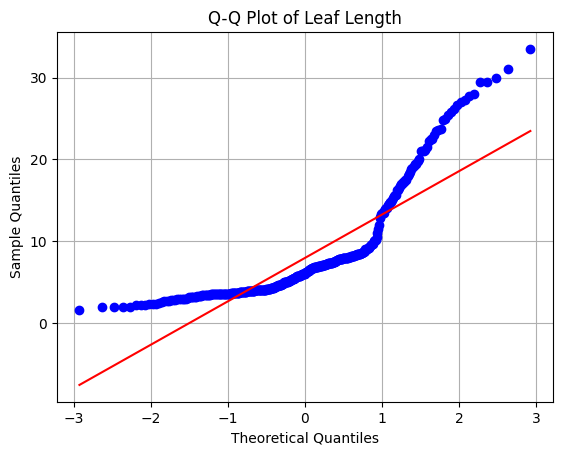

In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Q-Q plot of 'length'
stats.probplot(df['length'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Leaf Length")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()


In [10]:
df = df[['name','length', 'width']]



In [11]:
df.head()

,name,length,width
0,seetha,6.0,2.5
1,seetha,6.0,2.6
2,seetha,5.3,2.4
3,seetha,5.2,2.3
4,seetha,3.7,2.0


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df[['name', 'length']]
y = df['width']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [15]:
X_train

,name,length
3,seetha,5.2
18,seetha,5.4
202,pathar chatta,8.0
250,Neelamari (mitali),3.8
274,Sravanthi,5.0
...,...,...
71,mouha,19.5
106,Aswaganda,3.6
270,Sravanthi,4.0
348,jade plant,3.6


In [16]:
X_test

,name,length
209,pathar chatta,3.5
280,Anjeer,25.4
33,kaju,4.0
210,pathar chatta,8.1
93,lemon,2.2
...,...,...
246,Neelamari (mitali),6.4
227,Tej,7.8
369,muleti,7.7
176,conder,3.3


In [17]:
from sklearn.preprocessing import OneHotEncoder
oeh = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoded_train_name = oeh.fit_transform(X_train[['name']])
encoded_test_name = oeh.transform(X_test[['name']])

In [18]:
encoded_train_name

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [19]:
length_train = X_train[['length']].to_numpy()
length_test = X_test[['length']].to_numpy()


In [20]:
X_train_final_array = np.concatenate((length_train, encoded_train_name), axis=1)
X_test_final_array = np.concatenate((length_test, encoded_test_name), axis=1)

In [21]:
encoded_cols = oeh.get_feature_names_out(['name']).tolist()
final_columns = ['length'] + encoded_cols

In [22]:
X_train_final = pd.DataFrame(X_train_final_array, columns=final_columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_final_array, columns=final_columns, index=X_test.index)


In [23]:
X_train_final

,length,name_Anjeer,name_Aswaganda,name_Neelamari (mitali),name_Neem,name_Sravanthi,name_Tej,name_ajvine,name_conder,name_elachi,...,name_kaju,name_lemon,name_long,name_mouha,name_muleti,name_pathar chatta,name_sarso,name_seetha,name_sidha payam,name_tulsi
3,5.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18,5.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
250,3.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
274,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,19.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
106,3.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
348,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()
model.fit(X_train_final, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = model.predict(X_test_final)


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
mean_squared_error(y_test,y_pred)
a=mean_absolute_error(y_test,y_pred)


In [36]:
np.sqrt(mean_squared_error(y_test,y_pred))

0.8791073888445443

In [37]:
a

0.4982659952722899

In [38]:
r2_score(y_test,y_pred)

0.9631207723141557

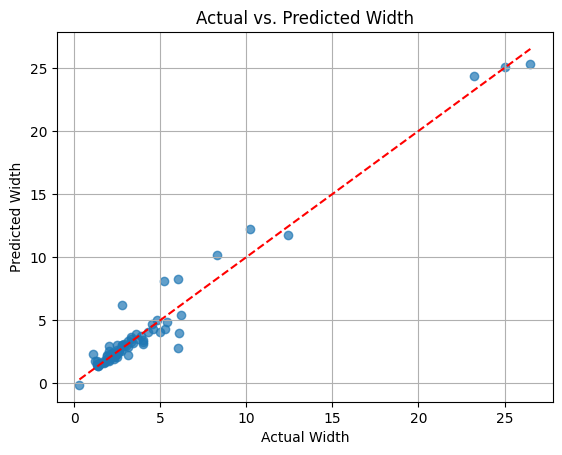

In [29]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Width')
plt.ylabel('Predicted Width')
plt.title('Actual vs. Predicted Width')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.show()


In [30]:
import joblib
joblib.dump(model, 'width_predictor_model.pkl')
joblib.dump(oeh, 'name_encoder.pkl')


['name_encoder.pkl']

#Prediction

In [31]:
loaded_model = joblib.load('width_predictor_model.pkl')
loaded_encoder = joblib.load('name_encoder.pkl')

new_data = pd.DataFrame([{'name': 'seetha', 'length': 6.0}])


new_encoded_name = loaded_encoder.transform(new_data[['name']])
new_log_length = np.log1p(new_data[['length']].to_numpy())


final_input = np.concatenate((new_log_length, new_encoded_name), axis=1)


predicted_width = loaded_model.predict(final_input)
print(f"Predicted width: {predicted_width[0]:.2f}")


Predicted width: 1.11


C:\Users\prabh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
